# Project: Predictive Maintenance for Renewable Assets  
## Multiclass Classification of Solar Inverter Condition

This notebook demonstrates a complete workflow for a **classification project** in renewable energy systems.

The project uses:
- environmental measurements
- inverter operational sensor data

The goal is to classify the inverter condition into:
- **normal**
- **warning**
- **fault**

A **Logistic Regression** model is used in this notebook for multiclass classification. This model is suitable for teaching because it is simple, interpretable, and effective for introducing classification workflows with tabular data.

The notebook demonstrates a full renewable energy classification workflow:
- loading and cleaning multiple datasets
- merging environmental and inverter sensor data
- engineering diagnostic features
- encoding class labels
- building a baseline classifier
- training a Logistic Regression multiclass model
- evaluating the classifier with accuracy, a classification report, and a confusion matrix
- interpreting model coefficients
- saving classification results

## Step 1. Import the Python libraries

In this first step, the Python libraries that will be used throughout the notebook are imported. These libraries are needed for data manipulation, visualization, preprocessing, classification, and model evaluation.


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


## Step 2. Load the datasets

In this step, the environmental dataset and the inverter sensor dataset are loaded. In practical renewable energy systems, these data sources often come from different monitoring systems and must be merged before analysis.


In [34]:
BASE_URL = "https://raw.githubusercontent.com/tskaneva/bip_2026_big_data_and_ai_in_res/main/data"

env_df = pd.read_csv(f"{BASE_URL}/sample_inverter_environment_data.csv")
sensor_df = pd.read_csv(f"{BASE_URL}/sample_inverter_sensor_data.csv")


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1077)>

## Step 3. Display the first rows and basic information

In this step, the first rows and structural information of both datasets are displayed. This helps confirm that the files were loaded correctly and provides an initial understanding of the available columns and data types.


In [4]:
print("ENVIRONMENTAL DATA")
print(env_df.head())
print(env_df.info())

print("\nSENSOR DATA")
print(sensor_df.head())
print(sensor_df.info())


ENVIRONMENTAL DATA
             timestamp  solar_irradiance_w_m2  ambient_temperature_c  \
0  2023-01-01 00:00:00                    0.0              12.914791   
1  2023-01-01 01:00:00                    0.0              14.183631   
2  2023-01-01 02:00:00                    0.0              13.134150   
3  2023-01-01 03:00:00                    0.0              12.865091   
4  2023-01-01 04:00:00                    0.0              12.298788   

   humidity_pct  
0     60.533662  
1     61.479126  
2     68.970911  
3     61.188941  
4     63.527936  
<class 'pandas.DataFrame'>
RangeIndex: 2162 entries, 0 to 2161
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   timestamp              2162 non-null   str    
 1   solar_irradiance_w_m2  2154 non-null   float64
 2   ambient_temperature_c  2154 non-null   float64
 3   humidity_pct           2162 non-null   float64
dtypes: float64(3), str(1)
memory

## Step 4. Convert the timestamp columns to datetime format

In this step, the timestamp columns are converted to datetime format. This is necessary because sorting, merging, and extracting time-based features depend on proper datetime values.


In [5]:
env_df["timestamp"] = pd.to_datetime(env_df["timestamp"])
sensor_df["timestamp"] = pd.to_datetime(sensor_df["timestamp"])


## Step 5. Sort the datasets chronologically

In this step, both datasets are sorted by time. Time-related datasets should be ordered correctly before cleaning and merging.


In [6]:
env_df = env_df.sort_values("timestamp").reset_index(drop=True)
sensor_df = sensor_df.sort_values("timestamp").reset_index(drop=True)


## Step 6. Remove duplicate timestamps

In this step, duplicate timestamps are removed. Duplicate records can distort the merge process and create inconsistent training samples.


In [7]:
env_df = env_df.drop_duplicates(subset="timestamp")
sensor_df = sensor_df.drop_duplicates(subset="timestamp")


## Step 7. Check missing values

In this step, missing values are counted in both datasets. Missing values are common in monitoring systems and need to be handled before training a classifier.


In [8]:
print("Missing values in environmental data:")
print(env_df.isna().sum())

print("\nMissing values in sensor data:")
print(sensor_df.isna().sum())


Missing values in environmental data:
timestamp                0
solar_irradiance_w_m2    8
ambient_temperature_c    8
humidity_pct             0
dtype: int64

Missing values in sensor data:
timestamp                 0
dc_voltage_v              0
dc_current_a              0
ac_power_kw               8
inverter_temperature_c    0
efficiency_pct            8
vibration_mm_s            0
inverter_status           0
dtype: int64


## Step 8. Set the timestamp as the index

In this step, the timestamp column becomes the index of both datasets. This makes resampling and alignment easier.


In [9]:
env_df = env_df.set_index("timestamp")
sensor_df = sensor_df.set_index("timestamp")


## Step 9. Resample both datasets to hourly frequency

In this step, the datasets are resampled to hourly frequency. The sample data is already hourly, but this step demonstrates a standard preprocessing operation used in practical projects.


In [10]:
env_df = env_df.resample("h").mean()
sensor_numeric = sensor_df.select_dtypes(include=[np.number]).resample("h").mean()
sensor_status = sensor_df[["inverter_status"]].resample("h").agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])

sensor_df = sensor_numeric.join(sensor_status, how="left")


## Step 10. Merge the datasets

In this step, the environmental and sensor datasets are merged by timestamp. This creates one dataset where each record contains both environmental conditions and inverter measurements.


In [11]:
df = env_df.join(sensor_df, how="inner")
print(df.head())
print("\nMerged dataset shape:", df.shape)


                     solar_irradiance_w_m2  ambient_temperature_c  \
timestamp                                                           
2023-01-01 00:00:00                    0.0              12.914791   
2023-01-01 01:00:00                    0.0              14.183631   
2023-01-01 02:00:00                    0.0              13.134150   
2023-01-01 03:00:00                    0.0              12.865091   
2023-01-01 04:00:00                    0.0              12.298788   

                     humidity_pct  dc_voltage_v  dc_current_a  ac_power_kw  \
timestamp                                                                    
2023-01-01 00:00:00     60.533662    428.318611      1.940454     0.000000   
2023-01-01 01:00:00     61.479126    395.667873      0.000000     1.281359   
2023-01-01 02:00:00     68.970911    409.367517      1.372034     1.241953   
2023-01-01 03:00:00     61.188941    416.009047      0.221830     0.194652   
2023-01-01 04:00:00     63.527936    428.437682 

## Step 11. Handle missing values after merging

In this step, missing values are handled using forward fill and backward fill. For time series operational data, this is often a practical choice because nearby values are usually more meaningful than a global average.


In [12]:
print("Missing values before filling:")
print(df.isna().sum())

df = df.ffill().bfill()

print("\nMissing values after filling:")
print(df.isna().sum())


Missing values before filling:
solar_irradiance_w_m2     8
ambient_temperature_c     8
humidity_pct              0
dc_voltage_v              0
dc_current_a              0
ac_power_kw               8
inverter_temperature_c    0
efficiency_pct            8
vibration_mm_s            0
inverter_status           0
dtype: int64

Missing values after filling:
solar_irradiance_w_m2     0
ambient_temperature_c     0
humidity_pct              0
dc_voltage_v              0
dc_current_a              0
ac_power_kw               0
inverter_temperature_c    0
efficiency_pct            0
vibration_mm_s            0
inverter_status           0
dtype: int64


## Step 12. Inspect the class distribution

In this step, the number of samples in each inverter condition class is counted. This is important in classification problems because class imbalance can affect model performance.


In [13]:
print(df["inverter_status"].value_counts())


inverter_status
normal     1977
warning     135
fault        48
Name: count, dtype: int64


## Step 13. Visualize key sensor variables over time

In this step, several important sensor variables are plotted over time. This helps identify operational patterns and possible abnormal behavior.


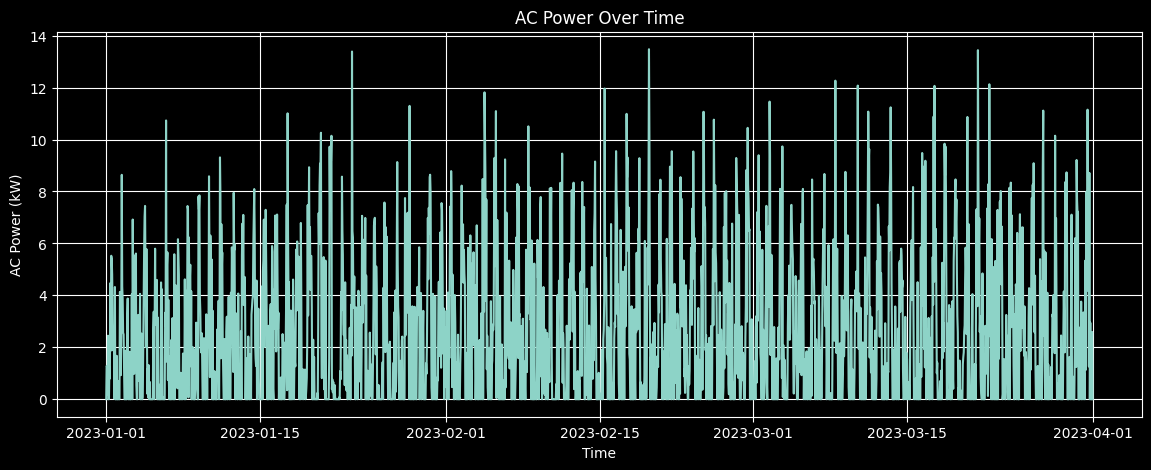

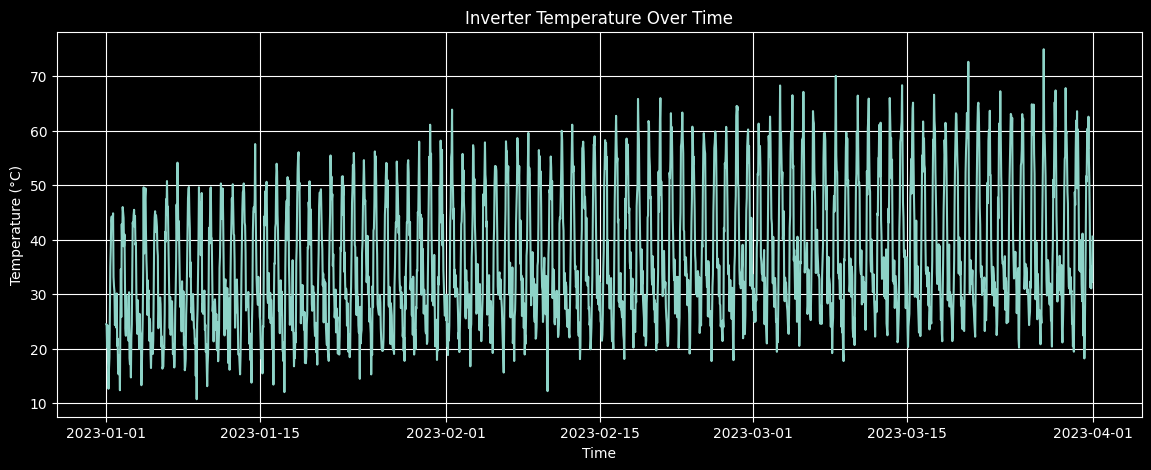

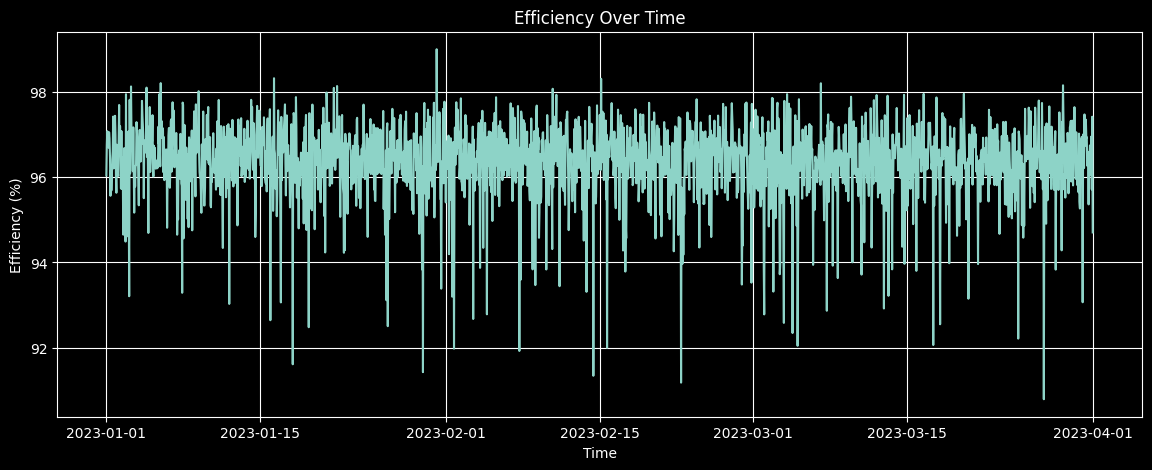

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["ac_power_kw"])
plt.title("AC Power Over Time")
plt.xlabel("Time")
plt.ylabel("AC Power (kW)")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["inverter_temperature_c"])
plt.title("Inverter Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["efficiency_pct"])
plt.title("Efficiency Over Time")
plt.xlabel("Time")
plt.ylabel("Efficiency (%)")
plt.grid(True)
plt.show()


## Step 14. Create time-based features

In this step, time-related features are created from the timestamp. Equipment behavior may depend on the hour of the day, the day of the week, and the month.


In [15]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)


## Step 15. Create cyclical time features

In this step, hour and day-of-week are transformed into sine and cosine values. This is useful because time variables are cyclical, and cyclical encoding preserves that repeating structure better than raw integer values.


In [16]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)


## Step 16. Create additional diagnostic features

In this step, a few derived variables are created. Feature engineering can help a classifier capture operational patterns more clearly.

The selected features are:
- power per irradiance, as a rough performance indicator
- temperature rise above ambient, as a thermal stress indicator


In [17]:
df["power_per_irradiance"] = df["ac_power_kw"] / (df["solar_irradiance_w_m2"] + 1e-6)
df["temp_rise_above_ambient"] = df["inverter_temperature_c"] - df["ambient_temperature_c"]


## Step 17. Encode the target classes as numbers

In this step, the text labels are converted into numeric codes. Machine learning classification models work with numeric targets.

The mapping is:
- normal → 0
- warning → 1
- fault → 2


In [18]:
class_mapping = {"normal": 0, "warning": 1, "fault": 2}
df["target_class"] = df["inverter_status"].map(class_mapping)

print(df[["inverter_status", "target_class"]].head())


                    inverter_status  target_class
timestamp                                        
2023-01-01 00:00:00          normal             0
2023-01-01 01:00:00          normal             0
2023-01-01 02:00:00          normal             0
2023-01-01 03:00:00          normal             0
2023-01-01 04:00:00          normal             0


## Step 18. Define the input features and the target

In this step, the feature columns and the target column are selected. The model will use both environmental and sensor-based variables to predict the inverter condition class.


In [19]:
feature_columns = [
    "solar_irradiance_w_m2",
    "ambient_temperature_c",
    "humidity_pct",
    "dc_voltage_v",
    "dc_current_a",
    "ac_power_kw",
    "inverter_temperature_c",
    "efficiency_pct",
    "vibration_mm_s",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "power_per_irradiance",
    "temp_rise_above_ambient"
]

X = df[feature_columns]
y = df["target_class"]


## Step 19. Split the dataset into training and testing sets

In this step, the dataset is split into training and testing sets. Stratification is used so that the class proportions remain similar in both subsets.

This notebook uses:
- 80% training data
- 20% testing data


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1728, 19)
Test shape: (432, 19)


## Step 20. Build a simple baseline classifier

In this step, a baseline is created by always predicting the most frequent class from the training set. This is useful because a classification model should perform better than this simple reference.


In [21]:
majority_class = y_train.mode()[0]
baseline_pred = np.full(len(y_test), majority_class)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
print("Majority class:", majority_class)
print(f"Baseline accuracy: {baseline_accuracy:.4f}")


Majority class: 0
Baseline accuracy: 0.9144


## Step 21. Scale the input features

In this step, the numerical input features are standardized. Logistic Regression usually performs better when the input variables are on comparable scales.


In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Step 22. Train the Logistic Regression classifier

In this step, a Logistic Regression model is trained for multiclass classification. The selected settings are practical for this type of problem:
- `max_iter=1000` allows enough iterations for convergence
- `random_state=42` ensures reproducibility


In [23]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## Step 23. Make predictions on the test set

In this step, the trained classifier predicts the inverter condition classes for the test set.


In [24]:
y_pred = model.predict(X_test_scaled)


## Step 24. Evaluate the classifier using accuracy

In this step, the classification accuracy is calculated. Accuracy is the proportion of correctly classified samples.


In [25]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression accuracy: {accuracy:.4f}")


Logistic Regression accuracy: 0.9653


## Step 25. Display the classification report

In this step, a classification report is generated. This report provides:
- precision
- recall
- F1-score

for each class, which gives a more complete picture than accuracy alone.


In [26]:
target_names = ["normal", "warning", "fault"]
print(classification_report(y_test, y_pred, target_names=target_names))


              precision    recall  f1-score   support

      normal       0.98      0.99      0.99       395
     warning       0.71      0.74      0.73        27
       fault       0.83      0.50      0.62        10

    accuracy                           0.97       432
   macro avg       0.84      0.74      0.78       432
weighted avg       0.96      0.97      0.96       432



## Step 26. Display the confusion matrix

In this step, the confusion matrix is displayed. This is one of the most important tools in classification because it shows which classes are confused with one another.


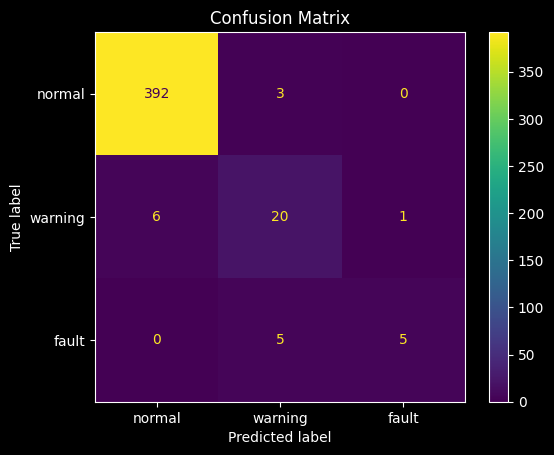

In [27]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


## Step 27. Compare actual and predicted class counts

In this step, the number of actual and predicted samples in each class is compared. This helps reveal whether the model overpredicts or underpredicts certain conditions.


In [28]:
comparison_df = pd.DataFrame({
    "Actual": pd.Series(y_test).value_counts().sort_index(),
    "Predicted": pd.Series(y_pred).value_counts().sort_index()
}, index=[0, 1, 2])

comparison_df.index = target_names
print(comparison_df)


         Actual  Predicted
normal      395        398
warning      27         28
fault        10          6


## Step 28. Interpret the model coefficients

In this step, the Logistic Regression coefficients are displayed. These values help explain how the input variables influence the probability of each class.


In [29]:
coef_df = pd.DataFrame(model.coef_, columns=feature_columns, index=target_names)
print(coef_df.T)


                           normal   warning     fault
solar_irradiance_w_m2    0.692142 -0.182403 -0.509739
ambient_temperature_c   -0.144038  0.426828 -0.282790
humidity_pct            -0.106379  0.127067 -0.020688
dc_voltage_v            -0.855556 -0.179385  1.034941
dc_current_a             1.211130 -0.175186 -1.035944
ac_power_kw              0.191058  0.390018 -0.581076
inverter_temperature_c  -1.023862  0.251111  0.772750
efficiency_pct           2.933942 -0.929821 -2.004121
vibration_mm_s          -0.885828  0.418764  0.467064
hour                    -0.040108  0.239596 -0.199488
day_of_week             -0.052861 -0.023276  0.076137
month                   -0.103004 -0.196746  0.299750
is_weekend               0.020320 -0.174800  0.154481
hour_sin                -0.391186  0.413214 -0.022027
hour_cos                -0.315128 -0.107983  0.423111
dow_sin                  0.053684 -0.064487  0.010803
dow_cos                  0.105747  0.088708 -0.194455
power_per_irradiance     0.3

## Step 29. Visualize selected model coefficients

In this step, the coefficients for one of the classes are plotted. This makes interpretation easier and helps show which features are most associated with a chosen class.


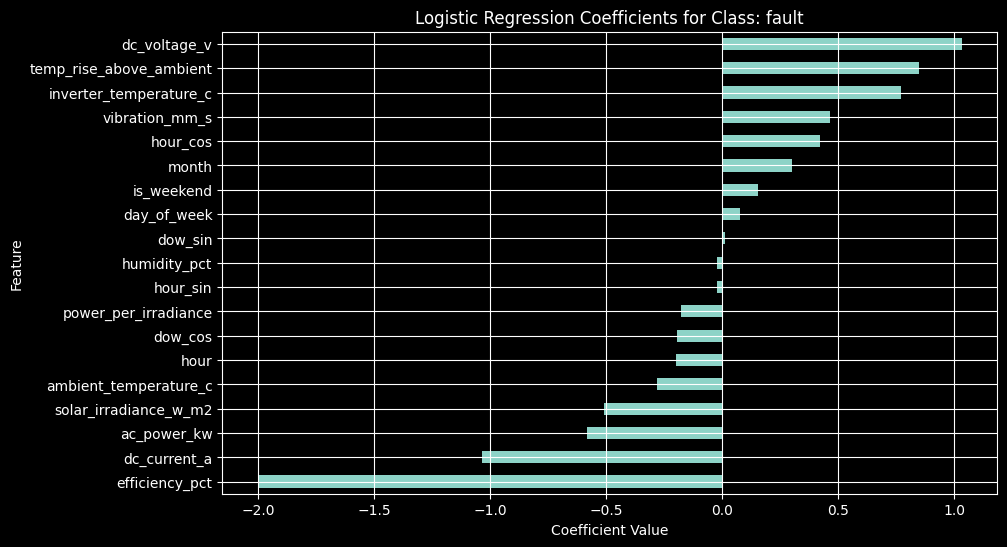

In [30]:
selected_class = "fault"

plt.figure(figsize=(10, 6))
coef_df.loc[selected_class].sort_values().plot(kind="barh")
plt.title(f"Logistic Regression Coefficients for Class: {selected_class}")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.grid(True)
plt.show()


## Step 30. Create a results table

In this step, a results table is created that contains:
- the actual class
- the predicted class

This is useful for manual inspection and further analysis.


In [31]:
inverse_class_mapping = {0: "normal", 1: "warning", 2: "fault"}

results_df = X_test.copy()
results_df["actual_class"] = y_test.map(inverse_class_mapping).values
results_df["predicted_class"] = pd.Series(y_pred, index=y_test.index).map(inverse_class_mapping).values

print(results_df.head())


                     solar_irradiance_w_m2  ambient_temperature_c  \
timestamp                                                           
2023-01-17 23:00:00               0.000000              19.852773   
2023-03-23 04:00:00               0.000000              16.498090   
2023-03-19 09:00:00             587.147233              15.389585   
2023-01-28 12:00:00             713.057952              12.150635   
2023-03-19 04:00:00               0.000000              14.822817   

                     humidity_pct  dc_voltage_v  dc_current_a  ac_power_kw  \
timestamp                                                                    
2023-01-17 23:00:00     53.119709    441.666893      0.000000     0.000000   
2023-03-23 04:00:00     68.347074    398.646733      0.478455     0.540502   
2023-03-19 09:00:00     56.464564    462.480333     10.673296     6.169622   
2023-01-28 12:00:00     52.062264    452.653599     13.340540     7.026642   
2023-03-19 04:00:00     63.790040    421.801628 

## Step 31. Save the classification results to a CSV file

In this step, the classification results are saved to a CSV file. This is useful for reporting, external visualization, or additional analysis outside the notebook.


In [32]:
results_df.to_csv("inverter_fault_classification_results.csv", index=False)
print("Results saved to inverter_fault_classification_results.csv")


Results saved to inverter_fault_classification_results.csv
